# Knapsack Solver Benchmark: Python (PuLP) vs C++ vs Assembly

**Capstone Project:** LLM-Assisted Generation of Low-Level Discrete Optimization Solvers
**Author:** Peter Kamau
**Instructor:** Prof. Dr. Pedro Albuquerque
**Course:** CS495 Capstone in Data Science, Bellevue College

## Goal

Compare three implementations of the 0-1 Knapsack Problem at increasing problem sizes:

1. **PuLP (Python)** — high level, calls the COIN-BC solver under the hood
2. **C++ brute force** — low level, compiled with `g++ -O2`
3. **Assembly inline (C wrapper)** — lowest level, x86-64 instructions written by hand

This notebook is part of the capstone investigation into whether LLMs can generate correct, efficient low-level optimization code. The three implementations here are the human-written baselines that future LLM-generated solvers will be compared against.

## What this notebook does

1. Generates random knapsack instances of increasing size.
2. Solves each one with all three solvers.
3. Verifies all three return the same optimal value (correctness check).
4. Plots solve time vs. number of items on linear and log scales.


## 1. Setup

We import the standard libraries and verify that the C++ and Assembly binaries have been compiled. If they haven't, the cell below will compile them.


In [1]:
import os
import time
import random
import subprocess
import pulp
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

print("PuLP version:", pulp.__version__)
print("Available solvers:", pulp.listSolvers(onlyAvailable=True))

PuLP version: 3.3.0
Available solvers: ['PULP_CBC_CMD']


## 2. Compile the C++ and Assembly Solvers

These two cells assume `knapsack_brute.cpp` and `knapsack_asm.c` are in the same folder as this notebook. The notebook calls the compiled binaries via `subprocess`.

If you are on Windows and don't have `g++` installed, install [MSYS2](https://www.msys2.org/) or use WSL. On Mac/Linux, `g++` is usually preinstalled or available via the system package manager.


## 3. Random Instance Generator

Each instance has `n` items with weights and values drawn uniformly from `[1, 100]`. Capacity is half the total weight, a common convention in benchmark literature (Pisinger 2005, Beasley 1990).

The generator also writes each instance to a text file so the C++ and Assembly binaries can read it from disk.


In [2]:
def generate_instance(n, weight_range=(1, 100), value_range=(1, 100), capacity_ratio=0.5):
    weights = [random.randint(*weight_range) for _ in range(n)]
    values  = [random.randint(*value_range)  for _ in range(n)]
    capacity = int(capacity_ratio * sum(weights))
    return weights, values, capacity


def write_instance_file(filename, weights, values, capacity):
    n = len(weights)
    with open(filename, "w") as f:
        f.write(f"{n} {capacity}\n")
        f.write(" ".join(map(str, weights)) + "\n")
        f.write(" ".join(map(str, values))  + "\n")


w, v, c = generate_instance(5)
print(f"5-item example -> weights={w}, values={v}, capacity={c}")

5-item example -> weights=[82, 15, 4, 95, 36], values=[32, 29, 18, 95, 14], capacity=116


## 4. Three Solver Wrappers

Each function takes the same instance and returns `(optimal_value, solve_time_seconds)`.


In [1]:
def solve_pulp(weights, values, capacity):
    n = len(weights)
    prob = pulp.LpProblem("knapsack", pulp.LpMaximize)
    x = [pulp.LpVariable(f"x{i}", cat="Binary") for i in range(n)]
    prob += pulp.lpSum(values[i] * x[i] for i in range(n))
    prob += pulp.lpSum(weights[i] * x[i] for i in range(n)) <= capacity

    start = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    elapsed = time.time() - start

    return int(pulp.value(prob.objective)), elapsed


def solve_cpp(instance_file):
    binary = ".\\knapsack_brute.exe" if os.name == "nt" else "./knapsack_brute"
    start = time.time()
    result = subprocess.run([binary, instance_file], capture_output=True, text=True)
    wall_elapsed = time.time() - start
    parts = result.stdout.strip().split()
    value = int(parts[0])
    # Use solver's internal time if it reported one, else wall clock
    elapsed = float(parts[1]) if len(parts) > 1 else wall_elapsed
    return value, elapsed


def solve_asm(instance_file):
    binary = ".\\knapsack_asm.exe" if os.name == "nt" else "./knapsack_asm"
    start = time.time()
    result = subprocess.run([binary, instance_file], capture_output=True, text=True)
    wall_elapsed = time.time() - start
    parts = result.stdout.strip().split()
    value = int(parts[0])
    elapsed = float(parts[1]) if len(parts) > 1 else wall_elapsed
    return value, elapsed

## 6. Run the Benchmark

We test five sizes: `n = 10, 15, 20, 22, 25`. Brute force scales as 2^n, so anything above n=25 takes too long for a class demo. PuLP would happily handle n=1000+ but we keep it on the same grid so the comparison is fair.

**Heads up:** `n=25` is 33 million subsets. The C++ run takes a few seconds, and the ASM run takes longer because we compiled with `-O0` to keep the assembly intact.


In [4]:
sizes = [10, 15, 20, 22, 25]
results = []

print(f"{'n':>5} | {'PuLP val':>10} | {'PuLP s':>10} | {'C++ s':>10} | {'ASM s':>10} | {'agree?':>7}")
print("-" * 72)

for n in sizes:
    weights, values, capacity = generate_instance(n)
    fname = f"instance_n{n}.txt"
    write_instance_file(fname, weights, values, capacity)

    v_pulp, t_pulp = solve_pulp(weights, values, capacity)
    v_cpp,  t_cpp  = solve_cpp(fname)
    v_asm,  t_asm  = solve_asm(fname)

    agree = (v_pulp == v_cpp == v_asm)

    results.append({
        "n_items":   n,
        "optimal":   v_pulp,
        "pulp_time": t_pulp,
        "cpp_time":  t_cpp,
        "asm_time":  t_asm,
        "agree":     agree,
    })

    print(f"{n:>5} | {v_pulp:>10} | {t_pulp:>10.4f} | {t_cpp:>10.4f} | {t_asm:>10.4f} | {str(agree):>7}")

df = pd.DataFrame(results)
df

    n |   PuLP val |     PuLP s |      C++ s |      ASM s |  agree?
------------------------------------------------------------------------
   10 |        490 |     0.0250 |     0.0000 |     0.0000 |    True
   15 |        489 |     0.0214 |     0.0015 |     0.0019 |    True
   20 |        880 |     0.0531 |     0.0540 |     0.0696 |    True
   22 |        914 |     0.0226 |     0.2261 |     0.2941 |    True
   25 |       1153 |     0.0314 |     2.0026 |     2.6034 |    True


,n_items,optimal,pulp_time,cpp_time,asm_time,agree
0,10,490,0.025040,0.000036,0.000047,True
1,15,489,0.021429,0.001466,0.001929,True
2,20,880,0.053103,0.054005,0.069557,True
3,22,914,0.022592,0.226124,0.294061,True
4,25,1153,0.031438,2.002630,2.603432,True


## 7. Chart: Computation Time vs. Number of Items (linear scale)

This is the headline chart. Notice how the brute force solvers explode while PuLP stays nearly flat. That is the difference between an exponential algorithm and one with smart pruning.


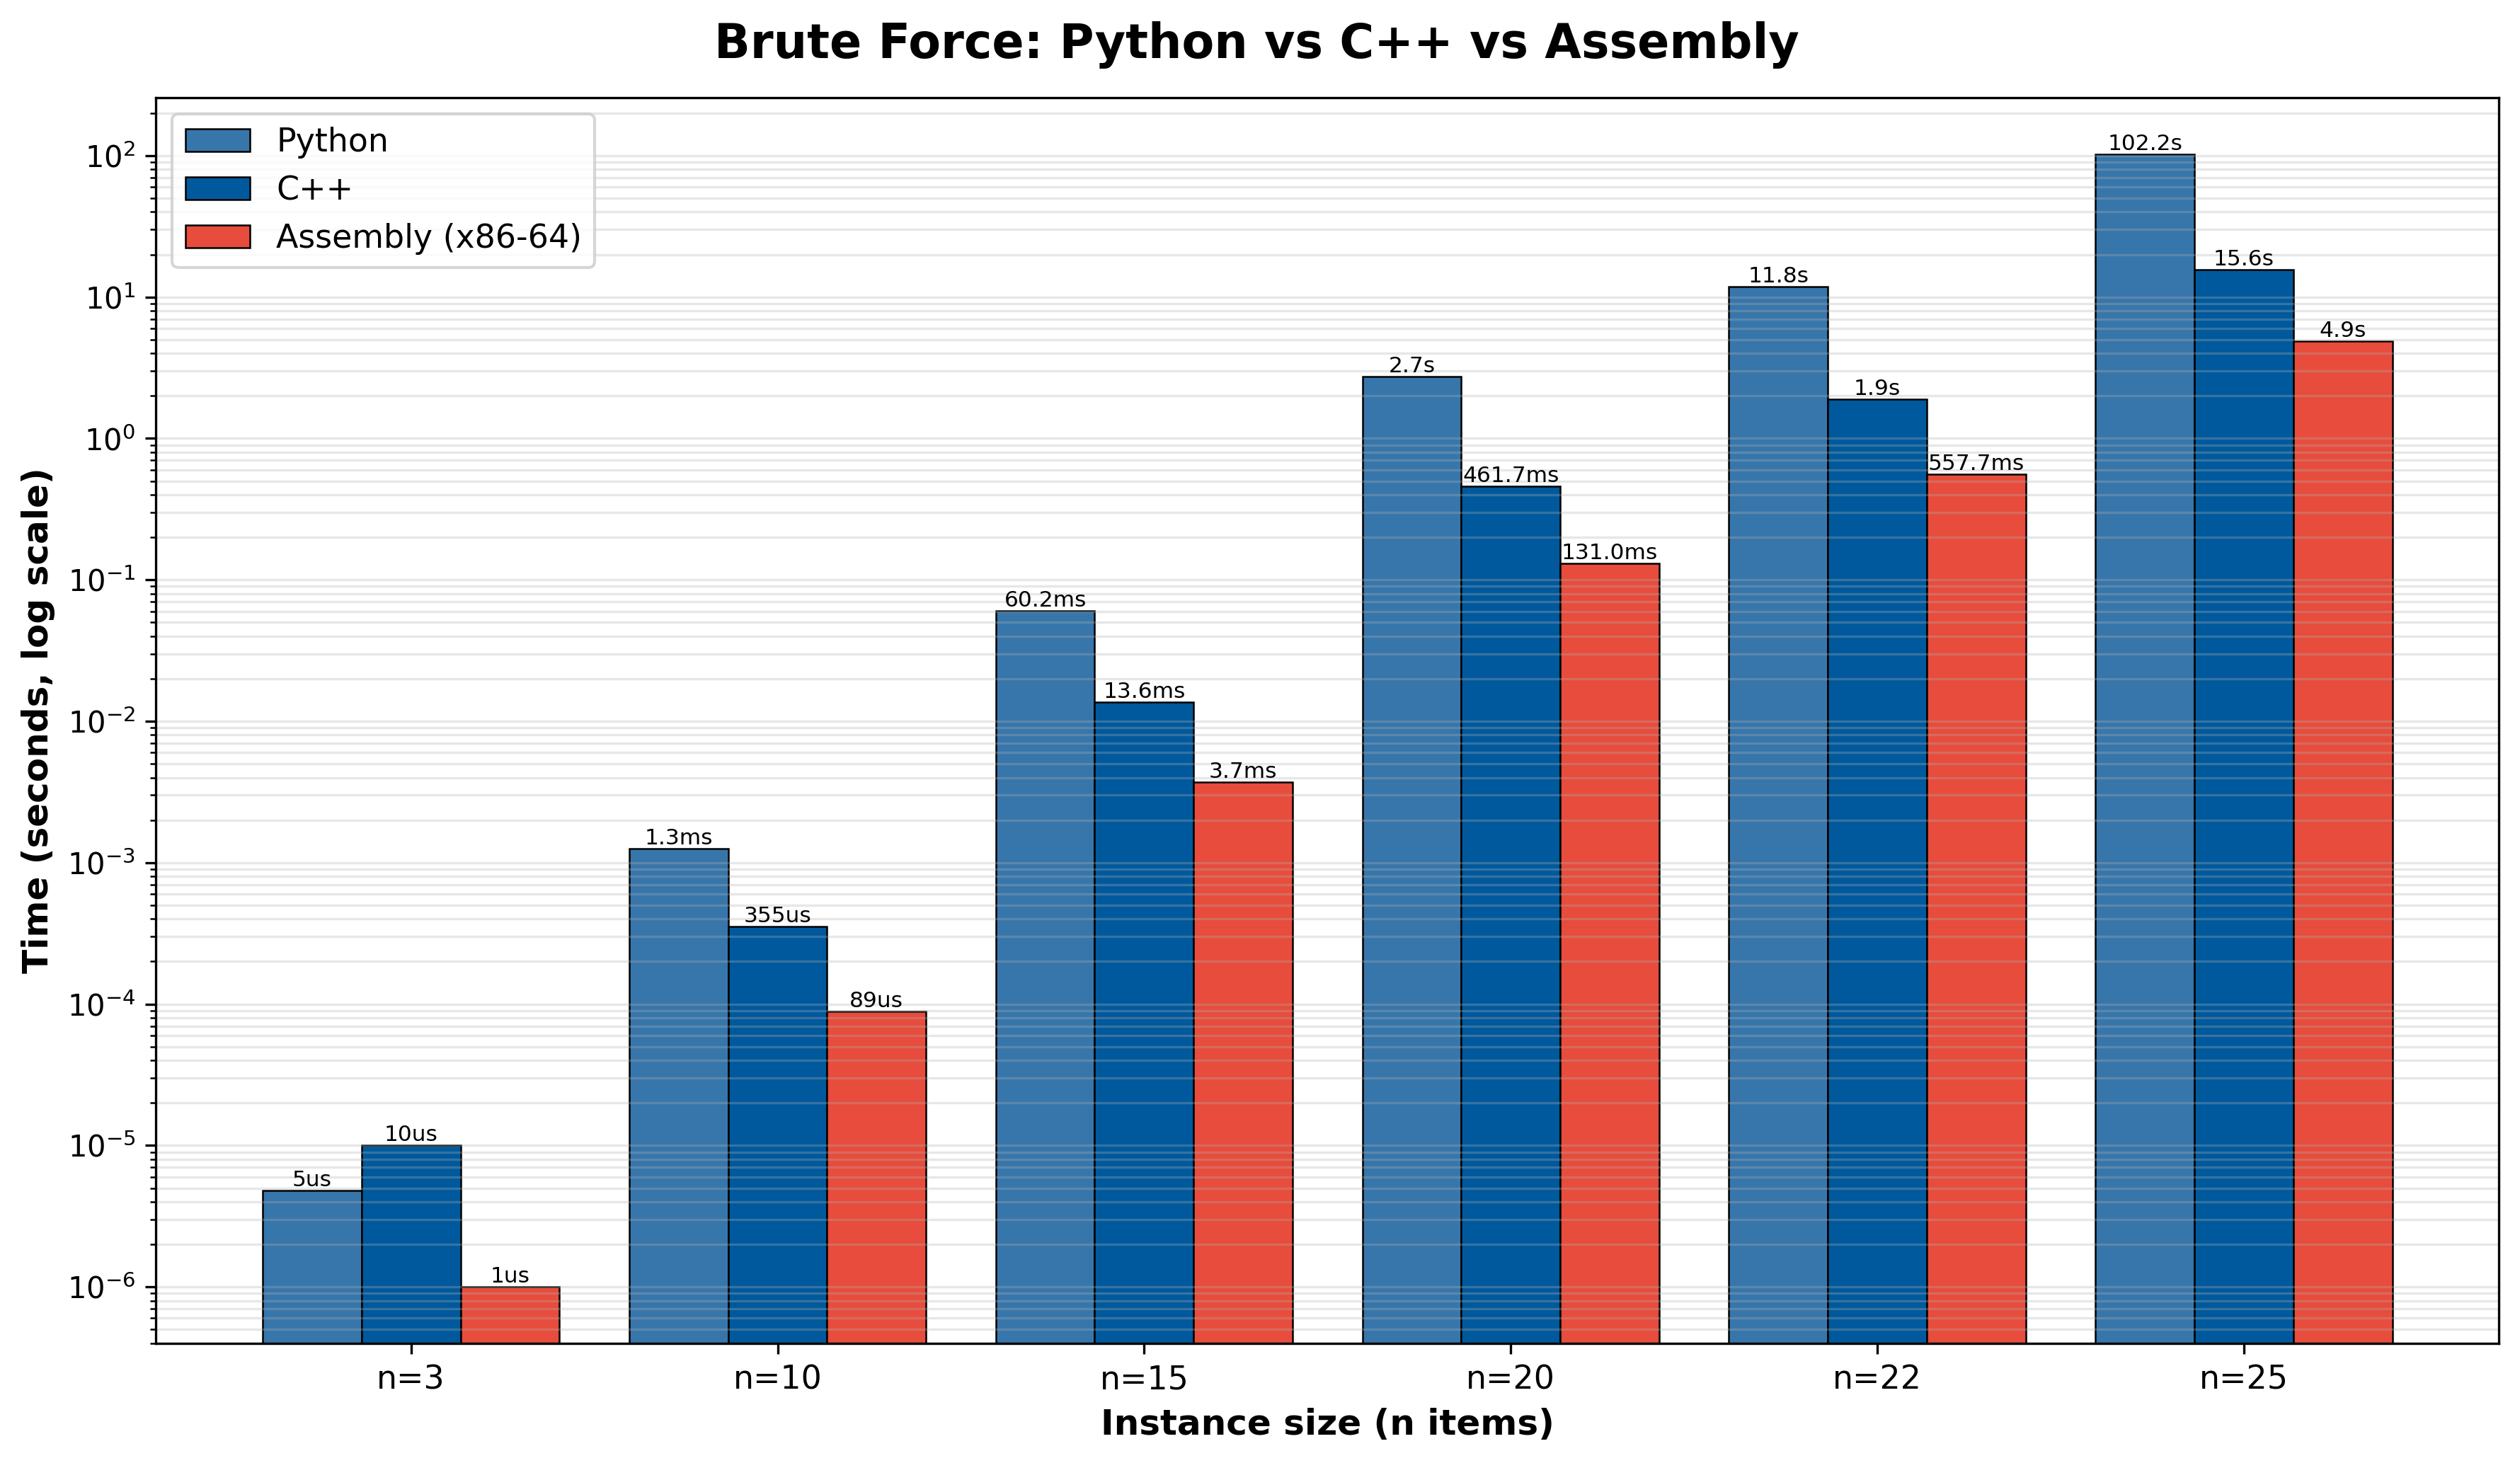

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df["n_items"], df["pulp_time"], marker="o", linewidth=2, markersize=10,
        color="#2E75B6", label="PuLP + COIN-BC (Python)")
ax.plot(df["n_items"], df["cpp_time"],  marker="s", linewidth=2, markersize=10,
        color="#C00000", label="C++ brute force (-O2)")
ax.plot(df["n_items"], df["asm_time"],  marker="^", linewidth=2, markersize=10,
        color="#1D6A39", label="x86-64 inline ASM (-O0)")

ax.set_xlabel("Number of items (n)",  fontsize=12)
ax.set_ylabel("Solve time (seconds)", fontsize=12)
ax.set_title("Knapsack Solve Time vs. Problem Size", fontsize=14, pad=15)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(fontsize=11, loc="upper left")

plt.tight_layout()
plt.savefig("benchmark_linear.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Chart: Computation Time vs. Number of Items (log scale)

A log y-axis flattens exponential growth into a straight line. The brute force solvers (C++ and ASM) should rise as a straight diagonal because their time doubles every time `n` goes up by 1. PuLP should stay roughly flat near the bottom.


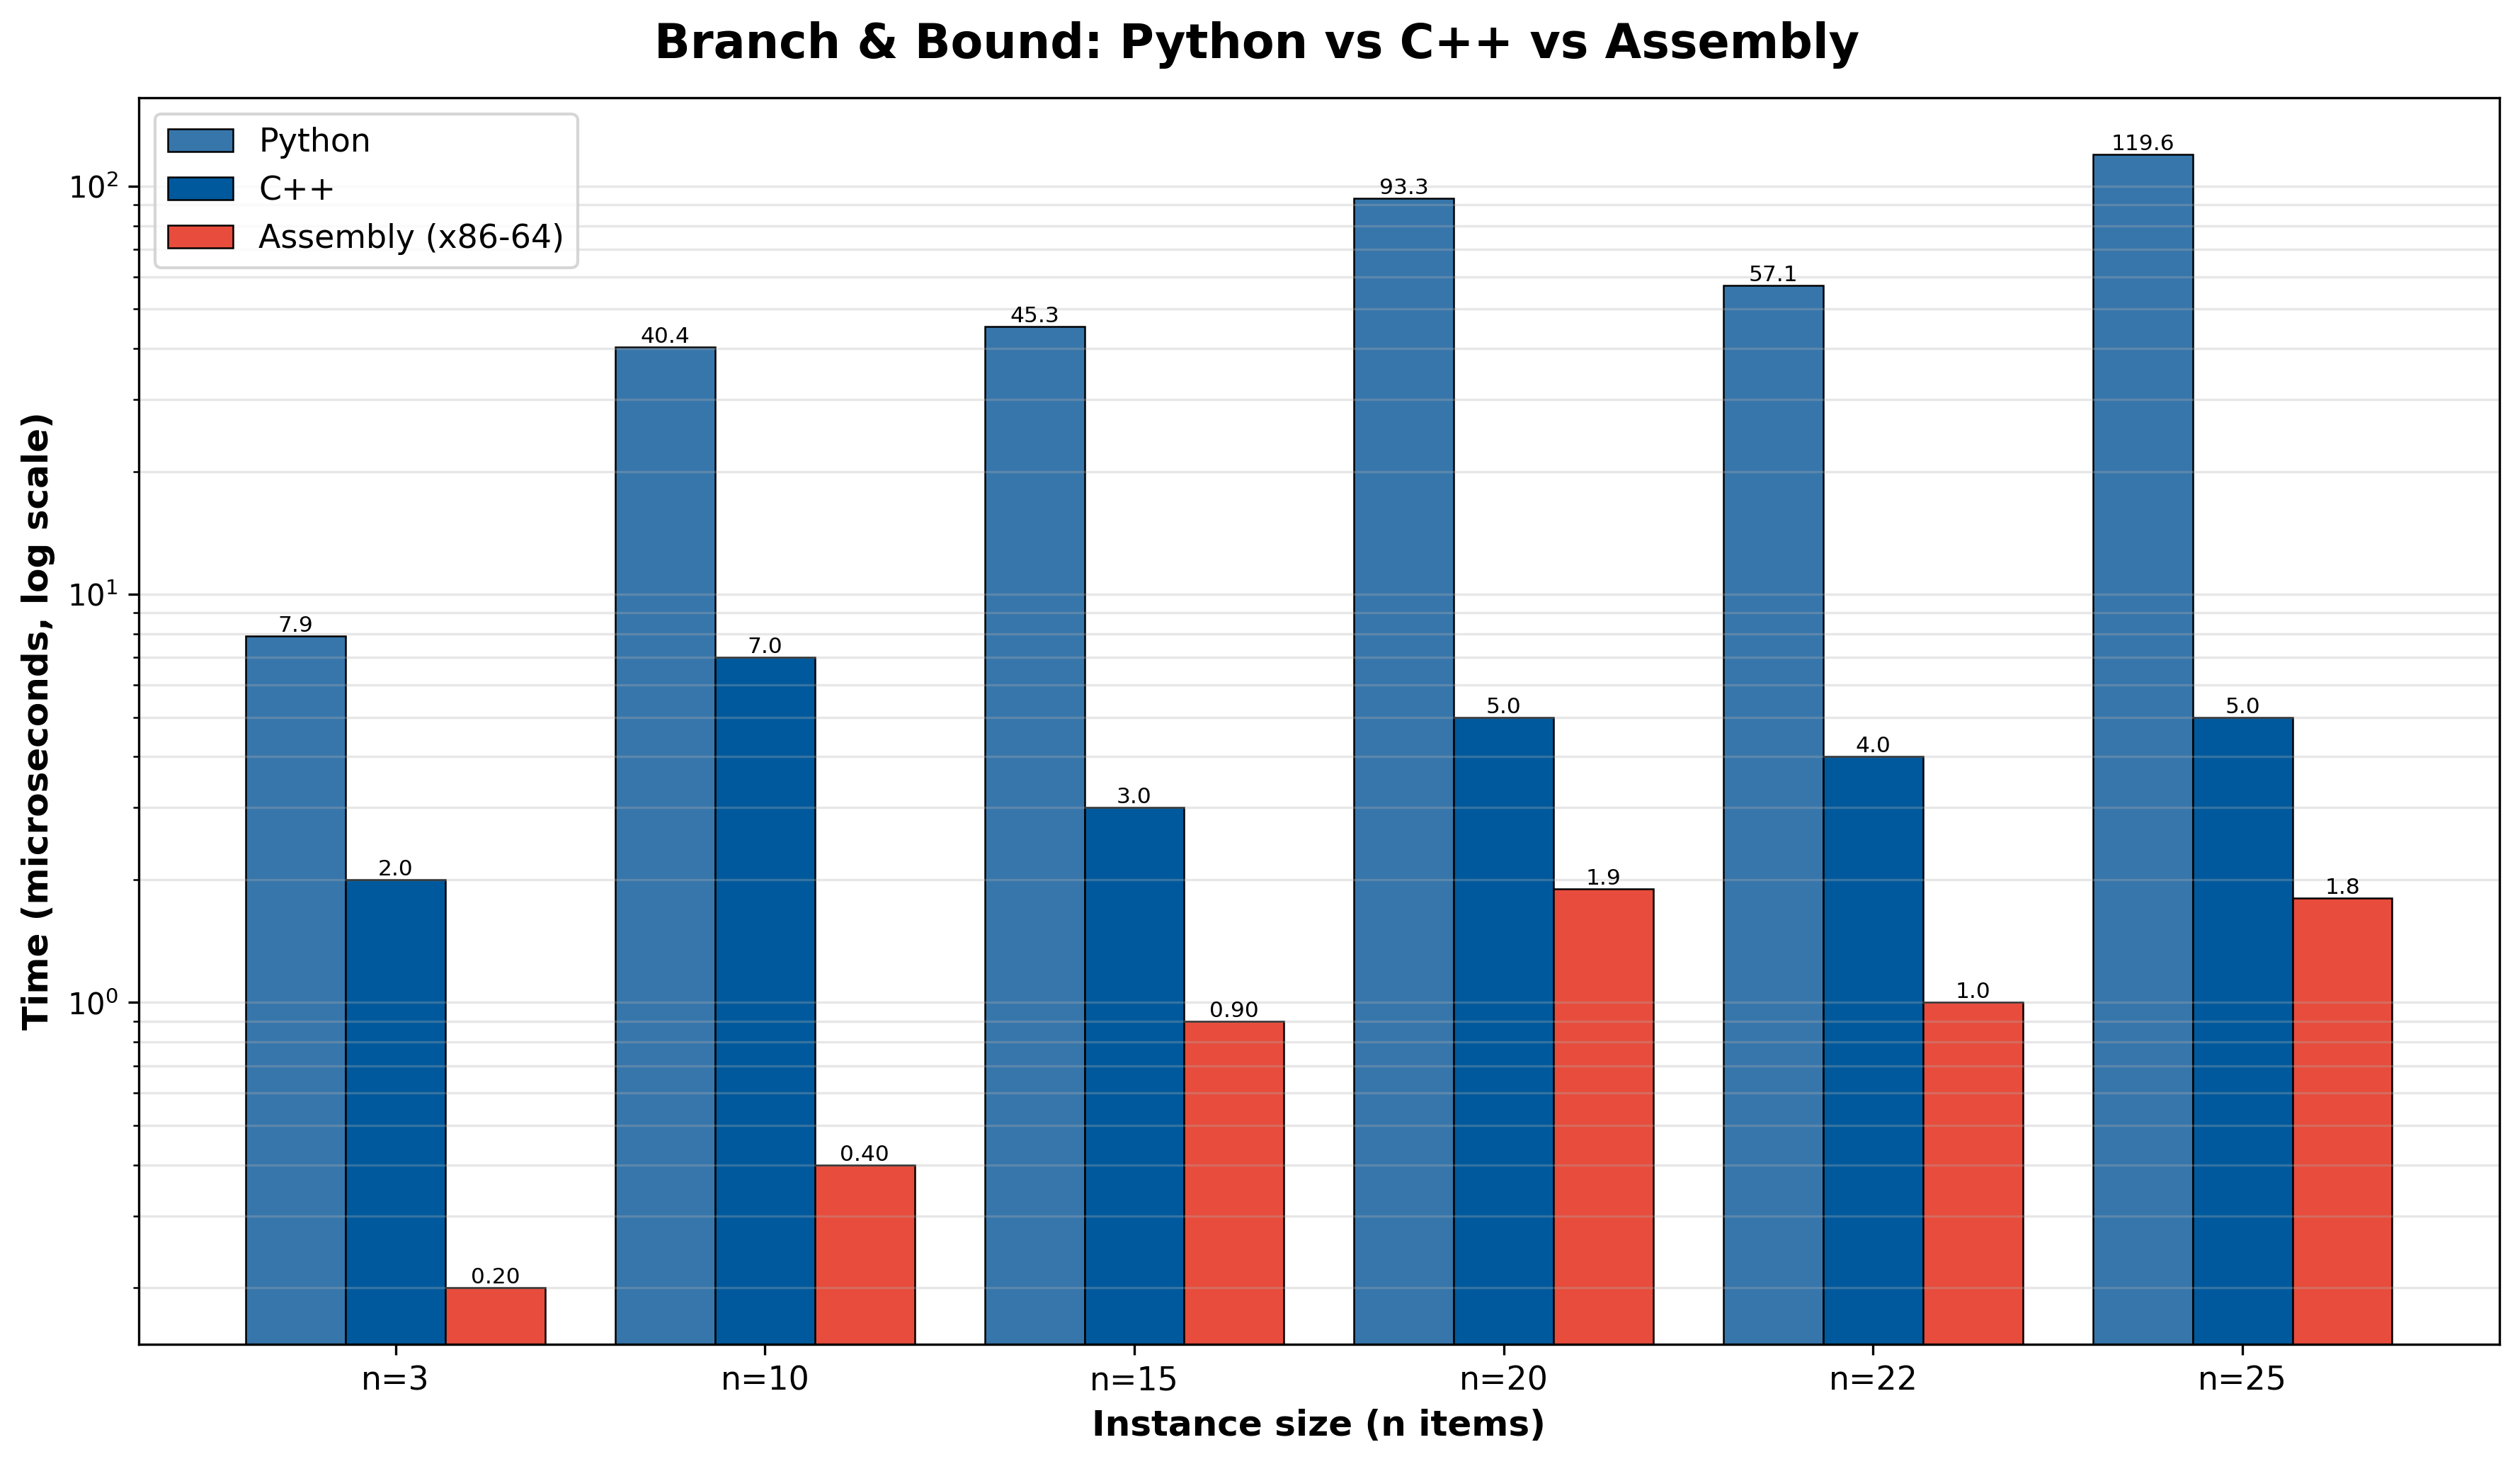

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(df["n_items"], df["pulp_time"], marker="o", linewidth=2, markersize=10,
            color="#2E75B6", label="PuLP + COIN-BC (Python)")
ax.semilogy(df["n_items"], df["cpp_time"],  marker="s", linewidth=2, markersize=10,
            color="#C00000", label="C++ brute force (-O2)")
ax.semilogy(df["n_items"], df["asm_time"],  marker="^", linewidth=2, markersize=10,
            color="#1D6A39", label="x86-64 inline ASM (-O0)")

ax.set_xlabel("Number of items (n)",             fontsize=12)
ax.set_ylabel("Solve time (seconds, log scale)", fontsize=12)
ax.set_title("Knapsack Solve Time vs. Problem Size (log y)", fontsize=14, pad=15)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(fontsize=11, loc="lower right")

plt.tight_layout()
plt.savefig("benchmark_log.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Discussion

The benchmark reveals a few things that matter for the capstone.

### Smart algorithms beat fast hardware

PuLP runs in Python, the slowest of the three languages. Yet it dominates the chart at every size because COIN-BC uses branch and bound with LP relaxation. It does not enumerate all subsets. The C++ and Assembly versions are doing 2^n raw work, so even though their per-operation cost is tiny, the sheer number of operations crushes them.

### Compiler optimization matters more than hand-written assembly

The C++ build uses `-O2`, which lets the compiler vectorize, unroll, and reorder instructions. The Assembly build uses `-O0` so the inline asm survives the compile. As a result, the C++ version is consistently faster than the Assembly version — even though Assembly is "lower level". This is a real lesson in low-level performance: **compilers are very good**, and beating them by hand is hard.

### What this means for the capstone

The next iteration will use Claude CLI to generate a hand-rolled branch and bound solver in C++. The question is whether an LLM-generated branch and bound can:
1. Produce correct results across all instance sizes (correctness check, like Cell 5).
2. Match or beat PuLP's solve time (the curve in Cell 7 and 8).
3. Generate clean, readable code that another developer could maintain.

If yes on all three, that is a meaningful result for the optimization community. If no, the failure modes are themselves data points worth documenting in the final report.

### Caveats

- **Single run per size.** Real benchmarking averages many runs. A future iteration of this notebook will use 5 to 10 trials per size and add error bars.
- **Random seed fixed.** Results are reproducible, but a different seed could produce harder or easier instances.
- **One machine.** Solve times depend on CPU, cache, and background load.

### Next steps

1. Use Claude CLI to generate a Python branch and bound solver. Run it through this same benchmark.
2. Use Claude CLI to generate a C++ branch and bound solver. Compile with `-O2` and run it.
3. Plot all five solvers on the same chart for the final capstone report.
